In [1]:
import pandas as pd
import numpy as np
from scipy.stats import hmean
import matplotlib.pyplot as plt
import os

In [2]:
nature_profiles_df = pd.read_csv("ability_profiles/ability_profiles_MaxAuxDiff=0_DupThresh=100.csv", index_col=0)

In [3]:
additional_profiles_df = pd.read_csv('data/additional_results_16June2026.csv', index_col=0)

In [4]:
ability_profiles_df = pd.concat([nature_profiles_df, additional_profiles_df], axis=0)

In [5]:
'''Collapser les ability profiles sur les dimensions du human scales'''
#On exploite la nomenclature des auteurs, dans laquelle chaque nom de groupe est constitué de deux lettres majuscules qui sont les deux premières lettres des dimensions qui le constituent
#Une exception à traiter à part : SNs
dimension_groups = list(set([name[:2] for name in ability_profiles_df.columns]))
dimensions = list(ability_profiles_df.columns)
#groupping_dict = {name : name[:2] for name in dimensions}
for dimension_group in dimension_groups:
    components = [dimension for dimension in dimensions if dimension[:2] == dimension_group]
    if len(components) >= 2:
        ability_profiles_df[dimension_group] = ability_profiles_df[components].apply(hmean, axis=1)
ability_profiles_df['SN'] = ability_profiles_df['SNs'].copy()

In [6]:
reduced_profiles_columns = list(dimension_groups)

In [7]:
reduced_profiles_df = ability_profiles_df[reduced_profiles_columns].copy()

In [8]:
rescaling_coefficients_df = pd.read_csv("data/rescaling_coefficients.csv")

In [9]:
rescaled_profiles_df = reduced_profiles_df.copy()

In [10]:
dimension_groups = [dimension_group for dimension_group in dimension_groups if dimension_group in rescaling_coefficients_df.columns]
for dimension_group in dimension_groups:
    rescaled_profiles_df[dimension_group] = rescaled_profiles_df[dimension_group].apply(lambda x: rescaling_coefficients_df[dimension_group].iloc[0]*x + rescaling_coefficients_df[dimension_group].iloc[1] - 0.5)

In [11]:
rescaled_profiles_df = rescaled_profiles_df[dimension_groups]

In [12]:
'''Fonctions d'affichage des radar plots. Héritées du github ADeLe (https://github.com/Kinds-of-Intelligence-CFI/ADeLe-AIEvaluation/blob/main/ability_profiles/scc_and_ability_profiles.ipynb) , avec de légères modifications.'''
def plot_radar_auc_subplots(auc_dict, feature_names, title="AUCs from Logistic Curves", level_diff=0, dup_threshold=100, max_level=9):
    """
    Create a radar plot comparing models using the area under their estimated logistic curves.
    """
    '''desired_order = [
        "AS", "CEc", "CEe", "CL", "MCr", "MCt", "MCu", "MS",
        "QLl", "QLq", "SNs", "KNa", "KNc", "KNf", "KNn", "KNs",
        "AT", "VO"
    ]'''
    #desired_order = order
    #feature_names = [feat for feat in desired_order if feat in feature_names]
    N = len(feature_names)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1] #Pourquoi ?

    fig, axes = plt.subplots(2, 2, figsize=(20, 20), subplot_kw=dict(polar=True))
    for i in range(2):
        for j in range(2):
            axes[i][j].set_theta_direction(-1)
            axes[i][j].set_theta_offset(np.pi/2)

    def plot_single_radar(ax, models_group, group_name):
        for model in models_group:
            display_name = name_mapping.get(model, model)
            values = [auc_dict[model][feat] for feat in feature_names] # donc : auc_dict : dictionnaire contenant un dictionnaire par modèle. Chaque sous-dictionnaire est un dictionnaire de features. Exemple minimal : {'GPT-4o' : {'AS' : 3.74}}
            values = [0 if np.isnan(v) else v for v in values]
            values += values[:1]

            if group_name == 'gpt_o1':
                alpha = dict(gpt_o1_models)[model]
                base_color = plt.cm.Reds(alpha)
            elif group_name == 'llama':
                alpha = dict(llama_models)[model]
                base_color = plt.cm.Blues(alpha)
            elif group_name == 'ds_r1':
                alpha = dict(ds_r1_models)[model]
                base_color = plt.cm.Greens(alpha)
            elif group_name == 'gemini':
                alpha = dict(gemini_models)[model]
                base_color = plt.cm.Purples(alpha)

            ax.plot(angles, values, label=display_name, color=base_color, linewidth=2)
            ax.fill(angles, values, alpha=0.25, color=base_color)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(feature_names, fontsize=10)
        ax.set_ylim(0, max_level)
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.4))

    plot_single_radar(axes[0][0], [model[0] for model in gpt_o1_models], 'gpt_o1')
    plot_single_radar(axes[0][1], [model[0] for model in llama_models], 'llama')
    plot_single_radar(axes[1][0], [model[0] for model in ds_r1_models], 'ds_r1')
    plot_single_radar(axes[1][1], [model[0] for model in gemini_models], 'gemini')

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    #plt.savefig(f"./figures/capability_radar_plot_MaxAuxDiff={level_diff}_DubThresh={dup_threshold}.pdf", bbox_inches='tight')
    plt.show()

In [13]:
gpt_o1_models = [
    ('babbage-002', 0.1),
    ('davinci-002', 0.2),
    ('gpt-35-turbo', 0.3),
    ('gpt4o', 0.4),
    ('o1-mini', 0.56),
    ('o1_re=low', 0.72),
    ('GPT-5.2-Chat', 0.88),
    ('OpenAI o3-mini', 1.0)
]

llama_models = [
    ('llama3d2-1b', 0.1),
    ('llama3d2-3b', 0.2),
    ('llama3d2-11b', 0.4),
    ('llama3d2-90b', 0.6),
    ('llama3d1-405b', 0.8),
    ('LLaMA-4-17B-128E', 1.0)
]

ds_r1_models = [
    ('DK-R1-Dist-Qwen-1.5B', 0.25),
    ('DK-R1-Dist-Qwen-7B', 0.50),
    ('DK-R1-Dist-Qwen-14B', 0.75),
    ('DK-R1-Dist-Qwen-32B', 1.0)
]

gemini_models = [
    ('Gemini-2.5-Flash', 0.33),
    ('Gemini-3.1-Flash', 0.66),
    ('Gemini-3.1-Pro', 1.0)
]

# Standardise the names
name_mapping = {
    'babbage-002': 'Babbage-002',
    'davinci-002': 'Davinci-002',
    'gpt-35-turbo': 'GPT-3.5-Turbo',
    'gpt4o': 'GPT-4o',
    'o1-mini': 'OpenAI o1-mini',
    'o1_re=low': 'OpenAI o1',
    'llama3d2-1b': 'LLaMA-3.2-1B-Instruct',
    'llama3d2-3b': 'LLaMA-3.2-3B-Instruct',
    'llama3d2-11b': 'LLaMA-3.2-11B-Instruct',
    'llama3d2-90b': 'LLaMA-3.2-90B-Instruct',
    'llama3d1-405b': 'LLaMA-3.1-405B-Instruct',
    'DK-R1-Dist-Qwen-1.5B': 'DK-R1-Dist-Qwen-1.5B',
    'DK-R1-Dist-Qwen-7B': 'DK-R1-Dist-Qwen-7B',
    'DK-R1-Dist-Qwen-14B': 'DK-R1-Dist-Qwen-14B',
    'DK-R1-Dist-Qwen-32B': 'DK-R1-Dist-Qwen-32B',
    'Gemini-2.5-Flash': 'Gemini-2.5-Flash',
    'Gemini-3.1-Flash': 'Gemini-3.1-Flash',
    'Gemini-3.1-Pro': 'Gemini-3.1-Pro',
    'LLaMA-4-17B-128E': 'LLaMA-4-17B-128E',
    'GPT-5.2-Chat': 'GPT-5.2-Chat',
    'OpenAI o3-mini': 'OpenAI o3-mini'
}

In [14]:
rescaled_dict = rescaled_profiles_df.transpose().to_dict()

In [15]:
reciprocal_name_mapping = {v : k for k, v in name_mapping.items()}

In [16]:
rescaled_dict = {reciprocal_name_mapping[k] : rescaled_dict[k] for k in rescaled_dict.keys()}

In [17]:
reduced_dict = reduced_profiles_df.transpose().to_dict()
reduced_dict = {reciprocal_name_mapping[k]: reduced_dict[k] for k in reduced_dict.keys()}

In [18]:
full_profile_dict = ability_profiles_df.transpose().to_dict()
full_profile_dict = {reciprocal_name_mapping[k]: full_profile_dict[k] for k in full_profile_dict.keys()}

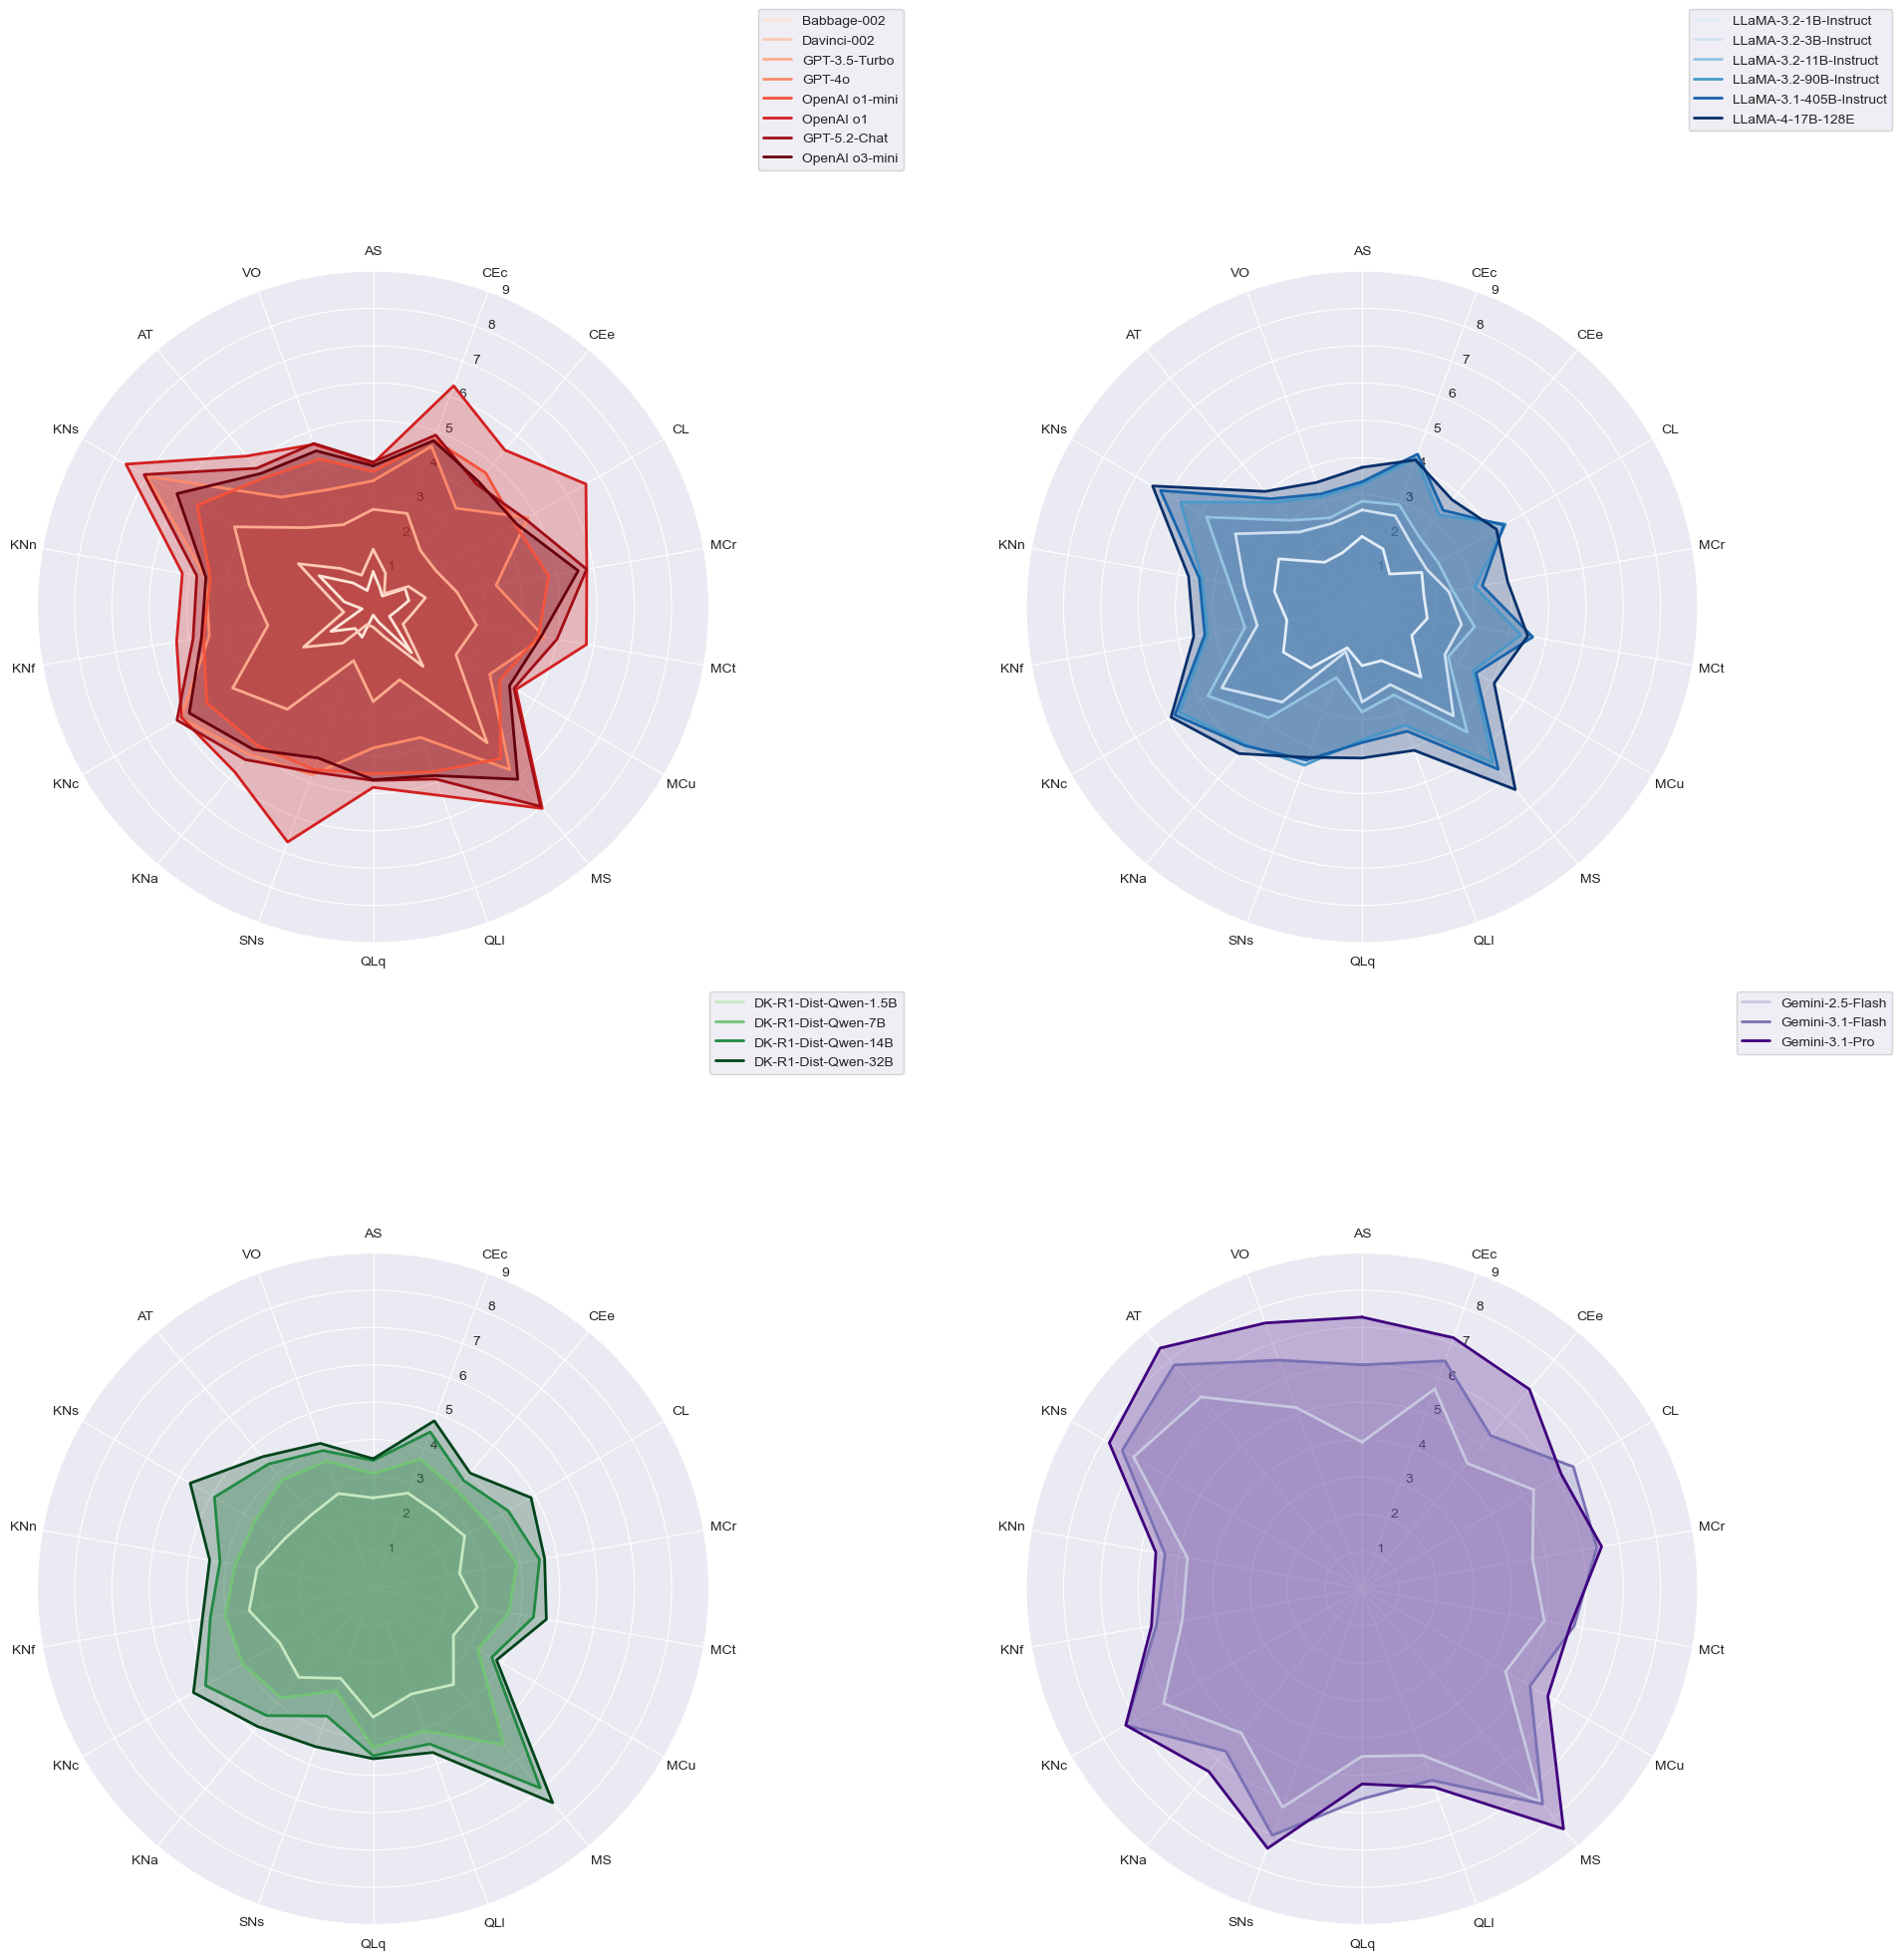

In [19]:
plot_radar_auc_subplots(full_profile_dict, feature_names=[
        "AS", "CEc", "CEe", "CL", "MCr", "MCt", "MCu", "MS",
        "QLl", "QLq", "SNs", "KNa", "KNc", "KNf", "KNn", "KNs",
        "AT", "VO"
    ])

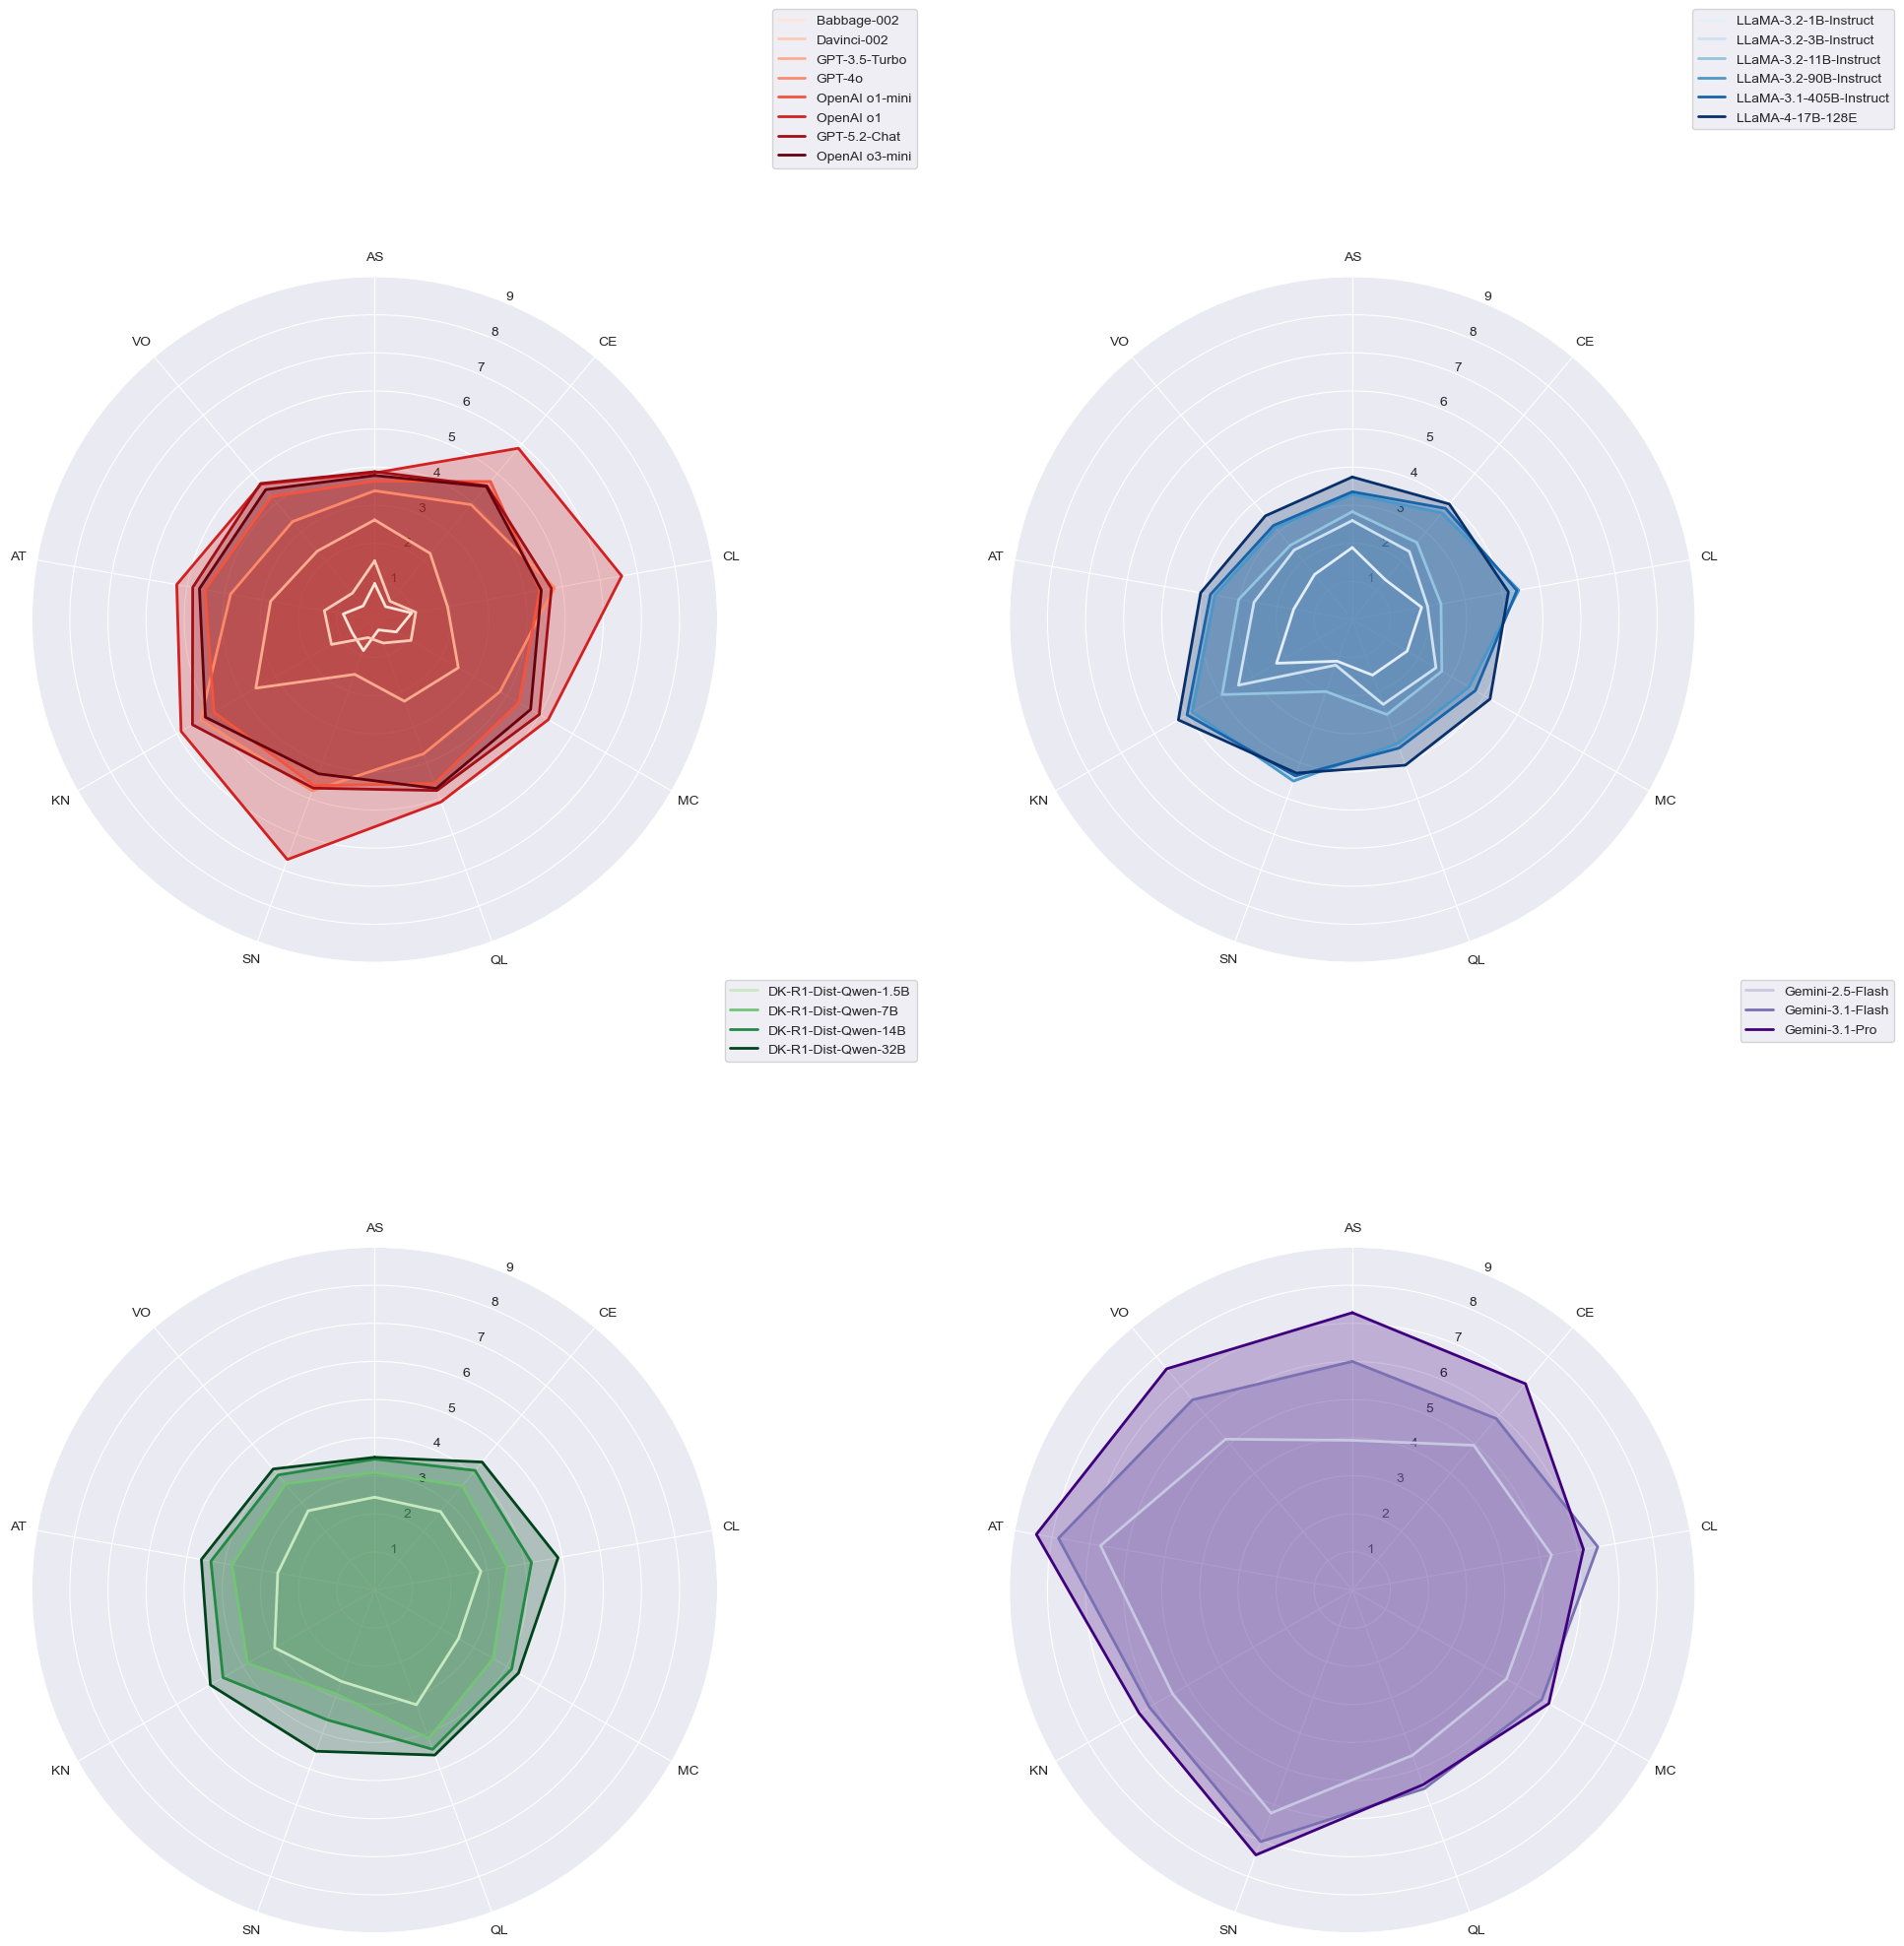

In [20]:
plot_radar_auc_subplots(reduced_dict, feature_names=['AS','CE', 'CL', 'MC', 'QL', 'SN', 'KN', 'AT', 'VO'])

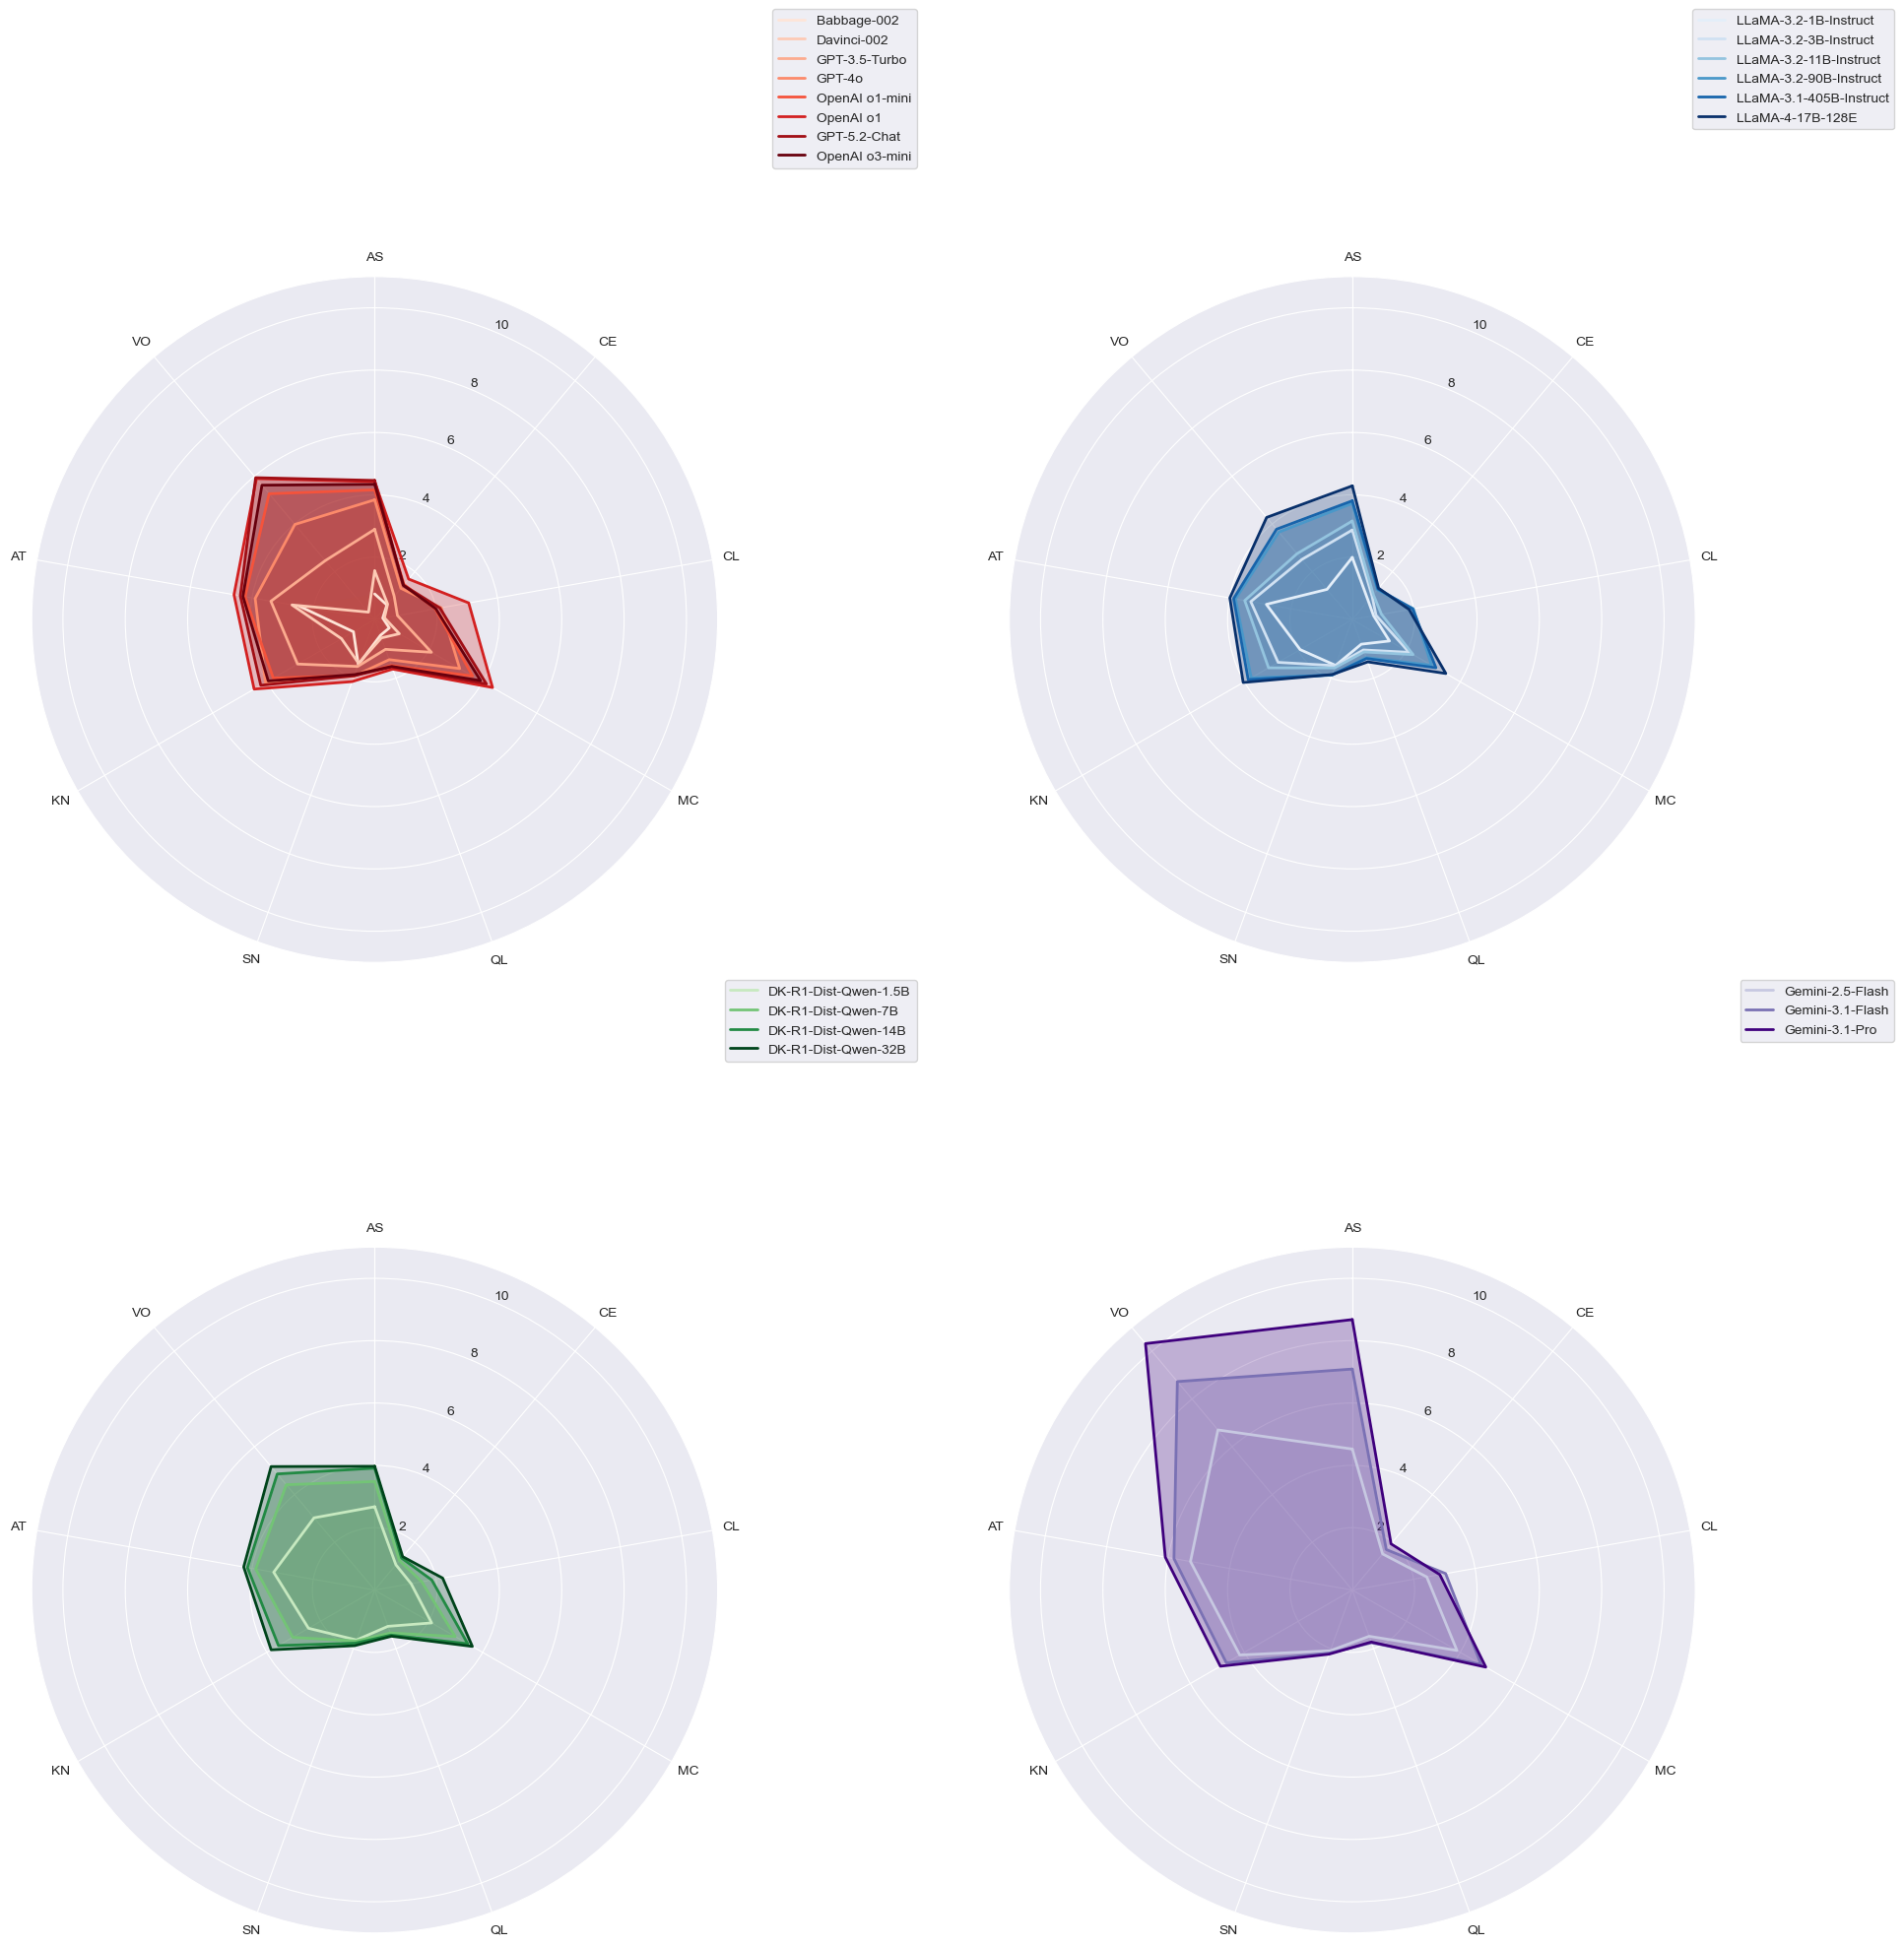

In [21]:
plot_radar_auc_subplots(rescaled_dict, feature_names=['AS','CE', 'CL', 'MC', 'QL', 'SN', 'KN', 'AT', 'VO'], max_level=11)